# 04 HEST-1k high-confidence HE-to-ST top256

这个 notebook 记录当前从 H&E 预测 ST 的第一版实验：在 high-confidence human Visium 子集上，预测 256 个代表性基因的表达 rate，并把已经选定的 SF predictor 接到 rate 后面，得到 count-scale ST 预测。

本 notebook 不重新训练模型，只做三件事：

1. 读取 high-confidence manifest、top256 gene list 和已经训练好的 checkpoint。
2. 重新计算 test split 的 SF、rate、count 指标，避免只看日志。
3. 画出一张空间 QC 图，把真实值和预测值叠在组织切片 thumbnail 上。


## 指标先解释清楚

- **SF / size factor**：每个 spot 的总捕获量相对本 slide 平均捕获量的倍数。这里固定使用 mean-one 定义，所以每张 slide 的真实 SF 平均值约为 1。
- **log_sf_pearson**：预测 `log(SF)` 和真实 `log(SF)` 的 Pearson 相关性。越高越好，说明模型能排出 spot 捕获强弱的空间趋势。
- **sf_std_ratio**：预测 SF 的标准差 / 真实 SF 的标准差。接近 1 更好；明显小于 1 说明模型把高低起伏抹平了。
- **sf_top_decile_mean_ratio**：真实 SF 最高 10% spot 中，模型预测的平均强度 / 真实平均强度。越接近 1，说明模型越能抓住高捕获量尾部区域。
- **rate**：去掉 SF 之后的表达率，近似表示“生物表达结构”。模型先预测 `log1p(rate)`。
- **count_no_sf**：只用预测 rate 当 count，不乘 SF。这是“不做捕获量校正”的 baseline。
- **count_pred_sf**：预测 count = 预测 rate × 预测 SF。这是当前真正的 H&E-to-ST 输出。
- **count_oracle_sf**：预测 rate × 真实 SF。真实 SF 不可能在推理时使用，所以它只表示上限：如果 SF 很准，count 预测最多能到什么程度。


In [1]:

from pathlib import Path
import json
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from torch.utils.data import DataLoader

ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "src" / "histoomnist").exists():
        ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate project root containing src/histoomnist.")
os.chdir(ROOT)
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from histoomnist.data.dataset import ExpressionRateDataset, FeatureStandardizer
from histoomnist.data.gene_selection import selected_genes_from_config
from histoomnist.data.spot_table import load_spot_table
from histoomnist.eval.evaluate_combined import evaluate, _load_rate_model, _load_sf_model
from histoomnist.train.common import load_checkpoint
from histoomnist.utils.config import get_device_name, load_config
from histoomnist.utils.io import read_manifest

pd.set_option("display.max_columns", 80)
plt.rcParams["figure.dpi"] = 130


In [2]:

paths = {
    "manifest": ROOT / "data/HEST-1k/manifests/human_visium_sf_manifest_highconf_context.csv",
    "genes": ROOT / "data/HEST-1k/manifests/highconf_top256_genes.txt",
    "gene_report": ROOT / "results/hest1k_human_visium_sf/highconf_top256_gene_selection.csv",
    "sf_config": ROOT / "configs/hest1k_human_visium_sf_context_distribution_light.yaml",
    "sf_checkpoint": ROOT / "checkpoints/hest1k_human_visium_sf/context_distribution_light_hipt256_leave_slide_out/best.pt",
    "expression_config": ROOT / "configs/hest1k_human_visium_expression_highconf_top256.yaml",
    "expression_checkpoint": ROOT / "checkpoints/hest1k_human_visium_expression/highconf_top256_rate/best.pt",
    "metrics_json": ROOT / "results/hest1k_human_visium_expression/highconf_top256_combined_test_metrics.json",
}

existence = pd.DataFrame(
    [{"name": key, "path": str(path.relative_to(ROOT)), "exists": path.exists()} for key, path in paths.items()]
)
display(existence)
assert existence["exists"].all(), "有必要文件不存在，请先完成前置训练或数据准备。"


,name,path,exists
0,manifest,data\HEST-1k\manifests\human_visium_sf_manifes...,True
1,genes,data\HEST-1k\manifests\highconf_top256_genes.txt,True
2,gene_report,results\hest1k_human_visium_sf\highconf_top256...,True
3,sf_config,configs\hest1k_human_visium_sf_context_distrib...,True
4,sf_checkpoint,checkpoints\hest1k_human_visium_sf\context_dis...,True
5,expression_config,configs\hest1k_human_visium_expression_highcon...,True
6,expression_checkpoint,checkpoints\hest1k_human_visium_expression\hig...,True
7,metrics_json,results\hest1k_human_visium_expression\highcon...,True


In [3]:

manifest = pd.read_csv(paths["manifest"])
genes = paths["genes"].read_text(encoding="utf-8").splitlines()
gene_report = pd.read_csv(paths["gene_report"])

print(f"High-confidence slides: {manifest.shape[0]}")
print(f"Selected genes: {len(genes)}")

split_organ = pd.crosstab(manifest["organ"], manifest["split"]).reindex(columns=["train", "val", "test"]).fillna(0).astype(int)
display(split_organ)

display(gene_report.head(20))


High-confidence slides: 234
Selected genes: 256


split,train,val,test
organ,,,
Bowel,51,7,15
Brain,29,4,9
Breast,6,1,1
Eye,4,1,1
Heart,29,4,9
Skin,44,6,13


,gene,slides_present,total_count,mean_count,detected_spots,detected_fraction
0,FTH1,133,11717654.0,30.692083,277360,0.726490
1,TMSB4X,133,18033016.0,47.233927,275978,0.722870
2,ACTB,133,11461495.0,30.021125,275655,0.722024
3,FTL,133,9902302.0,25.937126,271426,0.710947
4,UBC,133,11512696.0,30.155236,269877,0.706890
5,TMSB10,125,15117547.0,39.597432,265092,0.694356
6,ITM2B,134,3114871.0,8.158790,264396,0.692533
7,B2M,133,9370160.0,24.543285,263179,0.689345
8,UBA52,133,6287661.0,16.469287,261460,0.684843
9,ACTG1,126,13081464.0,34.264314,261414,0.684722


## 为什么先做 top256 gene

high-confidence 子集跨 organ、跨 study 后，所有 slide 的共同基因交集为 0。直接按矩阵列号拼接会把不同 panel 的基因错配，所以不能这样训练。

当前做法是：只在 train split 中选择出现 slide 数足够多、检测 spot 足够多的 256 个基因；每张 slide 只对实际测到的基因计算 loss 和指标，缺失基因用 mask 忽略。这一步的目的不是得到最终基因全集，而是先证明完整链路是否成立。


In [4]:

sf_config = load_config(paths["sf_config"])
expr_config = load_config(paths["expression_config"])

metrics = evaluate(
    sf_config=sf_config,
    expression_config=expr_config,
    sf_checkpoint=paths["sf_checkpoint"],
    expression_checkpoint=paths["expression_checkpoint"],
    split_names=["test"],
    out_json=paths["metrics_json"],
)


sf_log_sf_pearson: 0.796055
sf_sf_pearson: 0.725675
sf_log_sf_mae: 0.535186
sf_log_sf_rmse: 0.779052
sf_sf_std_ratio: 0.834174
sf_sf_top_decile_mean_ratio: 0.741196
sf_log_sf_top_decile_mae: 0.498401
rate_mean_gene_pearson: 0.395867
rate_median_gene_pearson: 0.378448
rate_valid_genes: 256.000000
count_no_sf_mean_gene_pearson: 0.487676
count_no_sf_median_gene_pearson: 0.489700
count_no_sf_valid_genes: 256.000000
count_pred_sf_mean_gene_pearson: 0.557678
count_pred_sf_median_gene_pearson: 0.573033
count_pred_sf_valid_genes: 256.000000
count_oracle_sf_mean_gene_pearson: 0.665928
count_oracle_sf_median_gene_pearson: 0.684873
count_oracle_sf_valid_genes: 256.000000


In [5]:

metrics = json.loads(paths["metrics_json"].read_text(encoding="utf-8"))
metric_rows = [
    ("SF", "log_sf_pearson", metrics["sf_log_sf_pearson"], "预测 log(SF) 和真实 log(SF) 的相关性"),
    ("SF", "sf_pearson", metrics["sf_sf_pearson"], "预测 SF 和真实 SF 的相关性"),
    ("SF", "sf_std_ratio", metrics["sf_sf_std_ratio"], "预测波动幅度 / 真实波动幅度，接近 1 更好"),
    ("SF", "sf_top_decile_mean_ratio", metrics["sf_sf_top_decile_mean_ratio"], "真实最高 10% SF 区域的尾部恢复程度"),
    ("Rate", "rate_mean_gene_pearson", metrics["rate_mean_gene_pearson"], "256 个基因逐基因相关性的平均值"),
    ("Rate", "rate_median_gene_pearson", metrics["rate_median_gene_pearson"], "256 个基因逐基因相关性的中位数"),
    ("Count", "count_no_sf_mean_gene_pearson", metrics["count_no_sf_mean_gene_pearson"], "不乘 SF 的 count baseline"),
    ("Count", "count_pred_sf_mean_gene_pearson", metrics["count_pred_sf_mean_gene_pearson"], "预测 rate 乘预测 SF 后的 count 相关性"),
    ("Count", "count_oracle_sf_mean_gene_pearson", metrics["count_oracle_sf_mean_gene_pearson"], "预测 rate 乘真实 SF 后的理论上限"),
]
metric_table = pd.DataFrame(metric_rows, columns=["group", "metric", "value", "meaning"])
display(metric_table)


,group,metric,value,meaning
0,SF,log_sf_pearson,0.796055,预测 log(SF) 和真实 log(SF) 的相关性
1,SF,sf_pearson,0.725675,预测 SF 和真实 SF 的相关性
2,SF,sf_std_ratio,0.834174,预测波动幅度 / 真实波动幅度，接近 1 更好
3,SF,sf_top_decile_mean_ratio,0.741196,真实最高 10% SF 区域的尾部恢复程度
4,Rate,rate_mean_gene_pearson,0.395867,256 个基因逐基因相关性的平均值
5,Rate,rate_median_gene_pearson,0.378448,256 个基因逐基因相关性的中位数
6,Count,count_no_sf_mean_gene_pearson,0.487676,不乘 SF 的 count baseline
7,Count,count_pred_sf_mean_gene_pearson,0.557678,预测 rate 乘预测 SF 后的 count 相关性
8,Count,count_oracle_sf_mean_gene_pearson,0.665928,预测 rate 乘真实 SF 后的理论上限


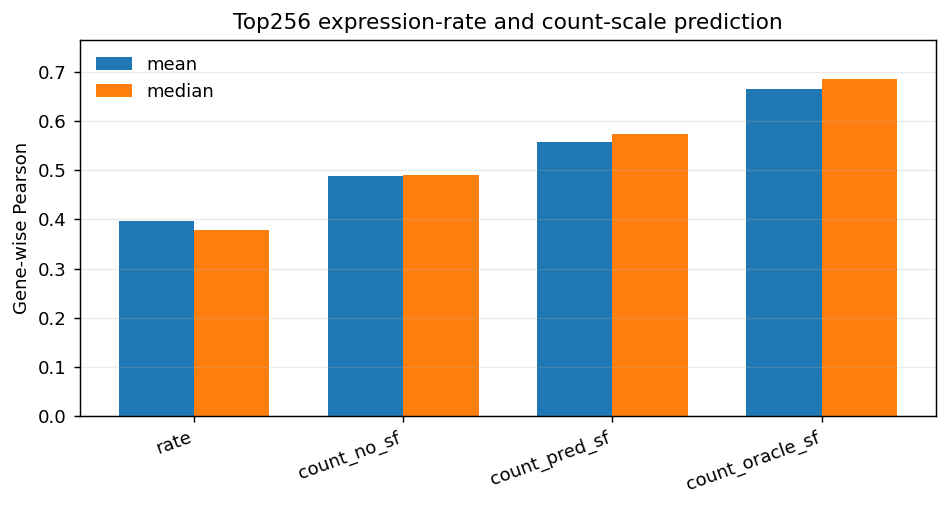

,setting,mean_gene_pearson,median_gene_pearson
0,rate,0.395867,0.378448
1,count_no_sf,0.487676,0.489700
2,count_pred_sf,0.557678,0.573033
3,count_oracle_sf,0.665928,0.684873


In [6]:

plot_df = pd.DataFrame(
    {
        "setting": ["rate", "count_no_sf", "count_pred_sf", "count_oracle_sf"],
        "mean_gene_pearson": [
            metrics["rate_mean_gene_pearson"],
            metrics["count_no_sf_mean_gene_pearson"],
            metrics["count_pred_sf_mean_gene_pearson"],
            metrics["count_oracle_sf_mean_gene_pearson"],
        ],
        "median_gene_pearson": [
            metrics["rate_median_gene_pearson"],
            metrics["count_no_sf_median_gene_pearson"],
            metrics["count_pred_sf_median_gene_pearson"],
            metrics["count_oracle_sf_median_gene_pearson"],
        ],
    }
)

fig, ax = plt.subplots(figsize=(7.4, 4.0))
x = np.arange(len(plot_df))
width = 0.36
ax.bar(x - width / 2, plot_df["mean_gene_pearson"], width, label="mean")
ax.bar(x + width / 2, plot_df["median_gene_pearson"], width, label="median")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["setting"], rotation=20, ha="right")
ax.set_ylabel("Gene-wise Pearson")
ax.set_ylim(0, max(plot_df["median_gene_pearson"].max(), plot_df["mean_gene_pearson"].max()) + 0.08)
ax.legend(frameon=False)
ax.set_title("Top256 expression-rate and count-scale prediction")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

display(plot_df)


## 当前判断

这组结果说明链路已经跑通：H&E 图像先预测表达 rate，再乘预测 SF，可以明显好于不使用 SF 的 count baseline。`count_pred_sf_mean_gene_pearson` 仍低于 `count_oracle_sf_mean_gene_pearson`，说明 SF 不是没用，而是还有改进空间。

因此下一步不是抛弃 SF，而是继续提升 SF 尾部恢复和跨 cohort 稳定性，同时把表达模型从 top256 扩展到更合理的基因集合或 pathway/gene module。


In [7]:

def collect_test_predictions(sf_config, expr_config):
    device = torch.device(get_device_name(expr_config.get("device")))
    sf_ckpt = load_checkpoint(paths["sf_checkpoint"], map_location=str(device))
    rate_ckpt = load_checkpoint(paths["expression_checkpoint"], map_location=str(device))
    manifest_path = Path(expr_config["data"]["manifest"])
    manifest_df = read_manifest(manifest_path)
    gene_names, gene_indices = selected_genes_from_config(expr_config, base_dir=manifest_path.parent)

    ds = ExpressionRateDataset(
        manifest_df,
        base_dir=manifest_path.parent,
        splits=["test"],
        min_total_counts=float(expr_config["data"].get("min_total_counts", 1.0)),
        standardizer=FeatureStandardizer(mean=rate_ckpt["feature_mean"], std=rate_ckpt["feature_std"]),
        gene_names=gene_names,
        gene_indices=gene_indices,
    )
    rate_model = _load_rate_model(expr_config, rate_ckpt, device)
    sf_model = _load_sf_model(sf_config, sf_ckpt, device)

    loader = DataLoader(ds, batch_size=int(expr_config["training"]["batch_size"]), shuffle=False)
    pred_rates, true_rates, masks = [], [], []
    with torch.no_grad():
        for batch in loader:
            pred_log1p_rate = rate_model(batch["features"].to(device)).cpu().numpy()
            pred_rates.append(np.expm1(pred_log1p_rate).clip(min=0.0))
            true_rates.append(np.expm1(batch["log1p_rate"].numpy()))
            masks.append(batch["expression_mask"].numpy().astype(bool))

    sf_standardizer = FeatureStandardizer(mean=sf_ckpt["feature_mean"], std=sf_ckpt["feature_std"])
    sf_features = sf_standardizer.transform(ds.raw_x)
    pred_log_sf = []
    with torch.no_grad():
        batch_size = int(sf_config["training"]["batch_size"])
        for start in range(0, sf_features.shape[0], batch_size):
            stop = min(start + batch_size, sf_features.shape[0])
            pred_log_sf.append(sf_model(torch.from_numpy(sf_features[start:stop]).to(device)).cpu().numpy())

    pred_sf = np.exp(np.concatenate(pred_log_sf, axis=0)).reshape(-1)
    for sample_id in np.unique(ds.sample_ids):
        idx = ds.sample_ids == sample_id
        pred_sf[idx] = pred_sf[idx] / (pred_sf[idx].mean() + 1e-8)

    true_log_sf = ds.true_log_sf.reshape(-1)
    true_sf = np.exp(true_log_sf)
    pred_rate = np.concatenate(pred_rates, axis=0)
    true_rate = np.concatenate(true_rates, axis=0)
    mask = np.concatenate(masks, axis=0)
    pred_count = pred_rate * pred_sf[:, None]
    true_count = true_rate * true_sf[:, None]

    return {
        "dataset": ds,
        "genes": gene_names,
        "pred_sf": pred_sf,
        "true_sf": true_sf,
        "pred_rate": pred_rate,
        "true_rate": true_rate,
        "pred_count": pred_count,
        "true_count": true_count,
        "mask": mask,
    }


pred = collect_test_predictions(sf_config, expr_config)
print(f"Test spots used for prediction: {len(pred['dataset'])}")
print(f"Test slides used for prediction: {pd.Series(pred['dataset'].sample_ids).nunique()}")


Test spots used for prediction: 93620
Test slides used for prediction: 39


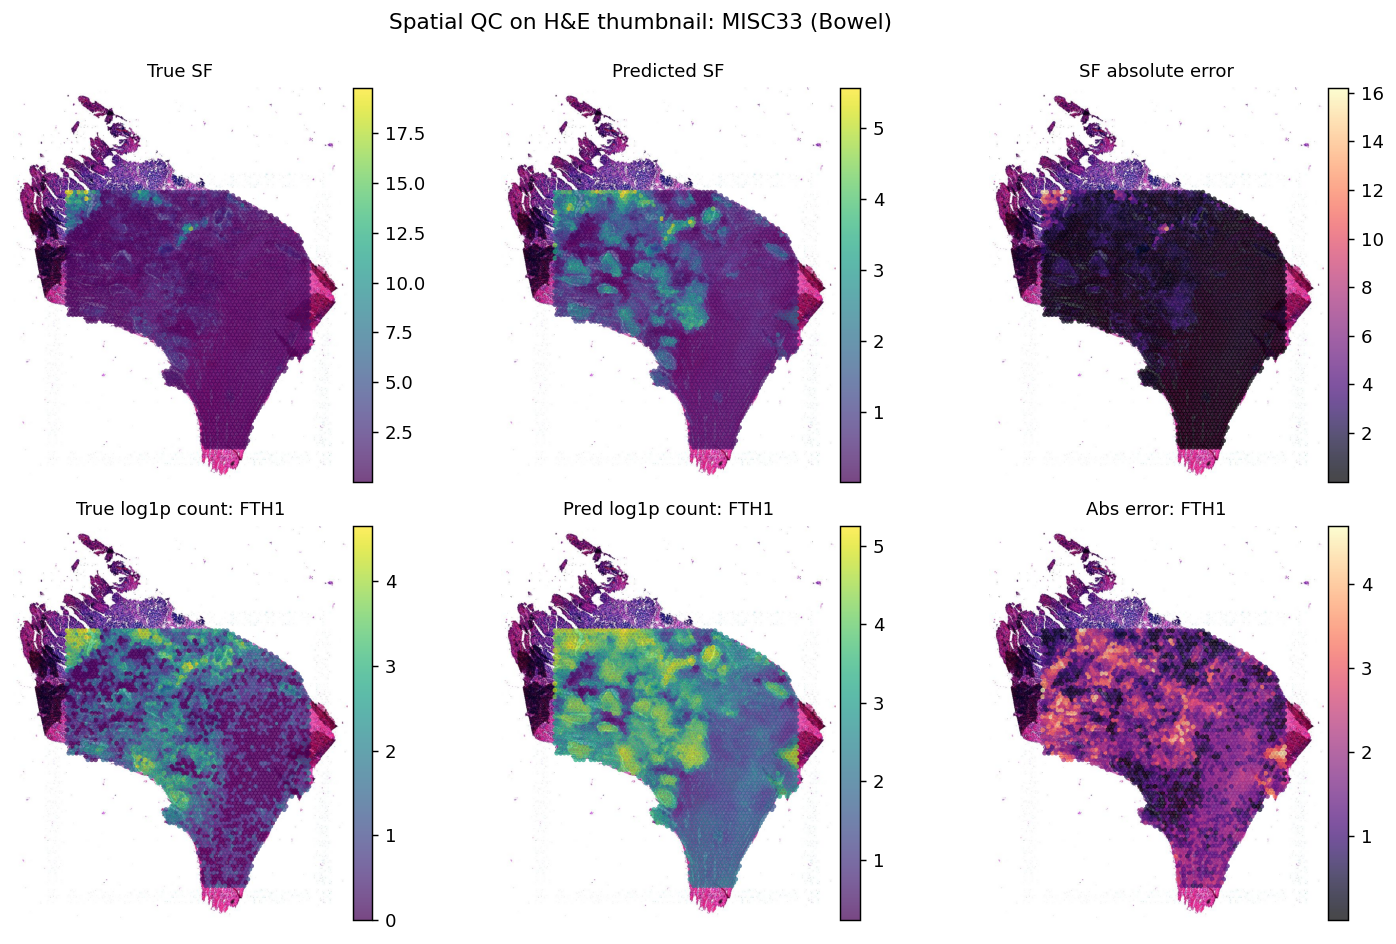

results\hest1k_human_visium_expression\highconf_top256_spatial_overlay_MISC33_FTH1.png


In [8]:

def coords_for_sample(sample_id: str):
    manifest_path = Path(expr_config["data"]["manifest"])
    manifest_df = read_manifest(manifest_path)
    row = manifest_df.loc[manifest_df["sample_id"] == sample_id].iloc[0]
    base_dir = manifest_path.parent
    table = load_spot_table(
        sample_id=sample_id,
        features_path=base_dir / str(row["features_path"]),
        counts_path=base_dir / str(row["counts_path"]),
        coords_path=base_dir / str(row["coords_path"]),
        size_factor_path=base_dir / str(row["size_factor_path"]),
        min_total_counts=float(expr_config["data"].get("min_total_counts", 1.0)),
    )
    return table.coords[table.valid_mask]


sample_id = "MISC33"
gene = "FTH1" if "FTH1" in pred["genes"] else pred["genes"][0]
gene_idx = pred["genes"].index(gene)
spot_idx = np.where(pred["dataset"].sample_ids == sample_id)[0]
coords = coords_for_sample(sample_id)
assert len(coords) == len(spot_idx), (len(coords), len(spot_idx))

present = pred["mask"][spot_idx, gene_idx]
coords_gene = coords[present]
idx_gene = spot_idx[present]

meta_path = ROOT / "data/HEST-1k/processed" / sample_id / "metadata.json"
meta = json.loads(meta_path.read_text(encoding="utf-8"))
thumb_path = ROOT / "data/HEST-1k/raw/thumbnails" / f"{sample_id}_downscaled_fullres.jpeg"
img = plt.imread(thumb_path)
img_h, img_w = img.shape[:2]
full_w = float(meta["fullres_px_width"])
full_h = float(meta["fullres_px_height"])
xy = np.column_stack([coords_gene[:, 0] / full_w * img_w, coords_gene[:, 1] / full_h * img_h])

panels = [
    (pred["true_sf"][idx_gene], "True SF", "viridis"),
    (pred["pred_sf"][idx_gene], "Predicted SF", "viridis"),
    (np.abs(pred["pred_sf"][idx_gene] - pred["true_sf"][idx_gene]), "SF absolute error", "magma"),
    (np.log1p(pred["true_count"][idx_gene, gene_idx]), f"True log1p count: {gene}", "viridis"),
    (np.log1p(pred["pred_count"][idx_gene, gene_idx]), f"Pred log1p count: {gene}", "viridis"),
    (
        np.abs(np.log1p(pred["pred_count"][idx_gene, gene_idx]) - np.log1p(pred["true_count"][idx_gene, gene_idx])),
        f"Abs error: {gene}",
        "magma",
    ),
]

fig, axes = plt.subplots(2, 3, figsize=(12, 7.2))
for ax, (values, title, cmap) in zip(axes.ravel(), panels):
    ax.imshow(img)
    sc = ax.scatter(xy[:, 0], xy[:, 1], c=values, s=7, cmap=cmap, alpha=0.72, linewidths=0)
    ax.set_title(title, fontsize=10)
    ax.set_axis_off()
    fig.colorbar(sc, ax=ax, fraction=0.040, pad=0.01)
fig.suptitle(f"Spatial QC on H&E thumbnail: {sample_id} ({meta.get('organ', '')})", y=0.99)
fig.tight_layout()
out_fig = ROOT / "results/hest1k_human_visium_expression" / f"highconf_top256_spatial_overlay_{sample_id}_{gene}.png"
out_fig.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_fig, bbox_inches="tight")
plt.show()
print(out_fig.relative_to(ROOT))


## 下一步实验

1. 先补充 per-organ、per-slide、per-gene 的误差分解，找出 top256 中哪些基因和哪些 organ 最稳定。
2. 对 SF predictor 做 tail-aware calibration，重点提高 `sf_top_decile_mean_ratio` 和 `sf_std_ratio`。
3. 把表达目标从 top256 扩展到更有生物意义的 gene module / pathway，并和单基因指标分开报告。
4. 完成 leave-cohort-out 和 leave-organ-out 的 HE-to-ST 评估，不能只看当前 test split。
